In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest,f_classif
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/fitness_dataset.csv')
df.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [ ]:
df.shape

(2000, 11)

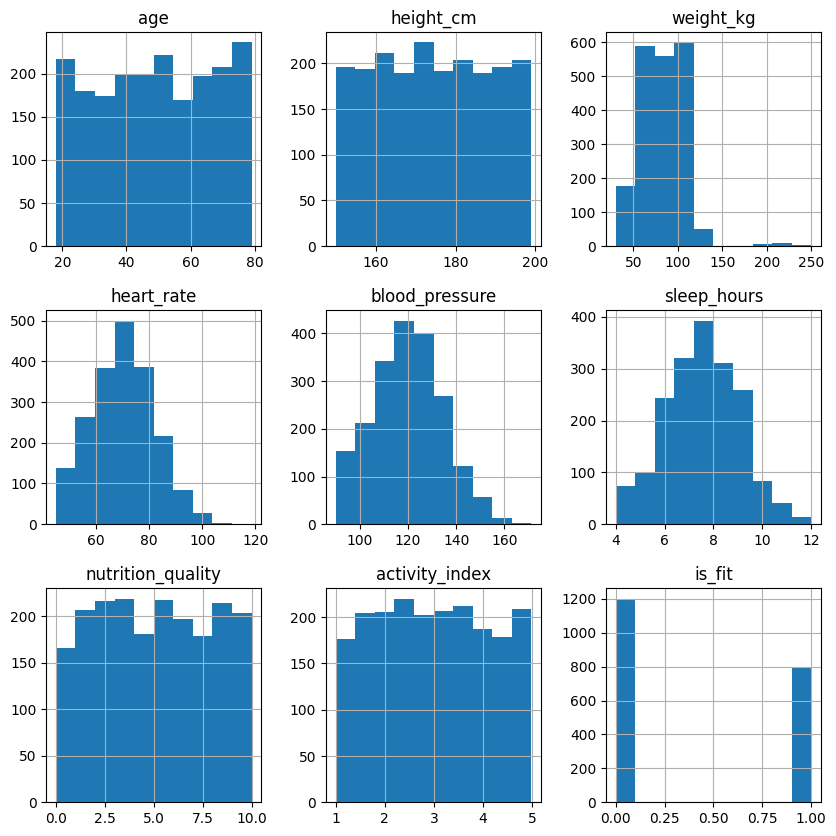

In [ ]:
df.hist(figsize = (10, 10))
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
age,0
height_cm,0
weight_kg,0
heart_rate,0
blood_pressure,0
sleep_hours,160
nutrition_quality,0
activity_index,0
smokes,0
gender,0


In [ ]:
df.describe()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,is_fit
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,1840.000000,2000.000000,2000.000000,2000.000000
mean,49.114000,174.53300,83.540500,70.288600,119.908850,7.513315,5.035140,2.999040,0.399500
std,17.926564,14.37175,25.852534,11.846339,14.578032,1.502031,2.864156,1.136383,0.489918
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000,0.000000
25%,34.000000,162.00000,64.000000,62.100000,109.700000,6.500000,2.547500,2.037500,0.000000
50%,49.000000,174.00000,83.000000,70.250000,120.000000,7.500000,5.065000,2.980000,0.000000
75%,65.000000,187.00000,102.000000,78.425000,129.800000,8.600000,7.470000,3.950000,1.000000
max,79.000000,199.00000,250.000000,118.600000,171.200000,12.000000,10.000000,4.990000,1.000000


<Axes: >

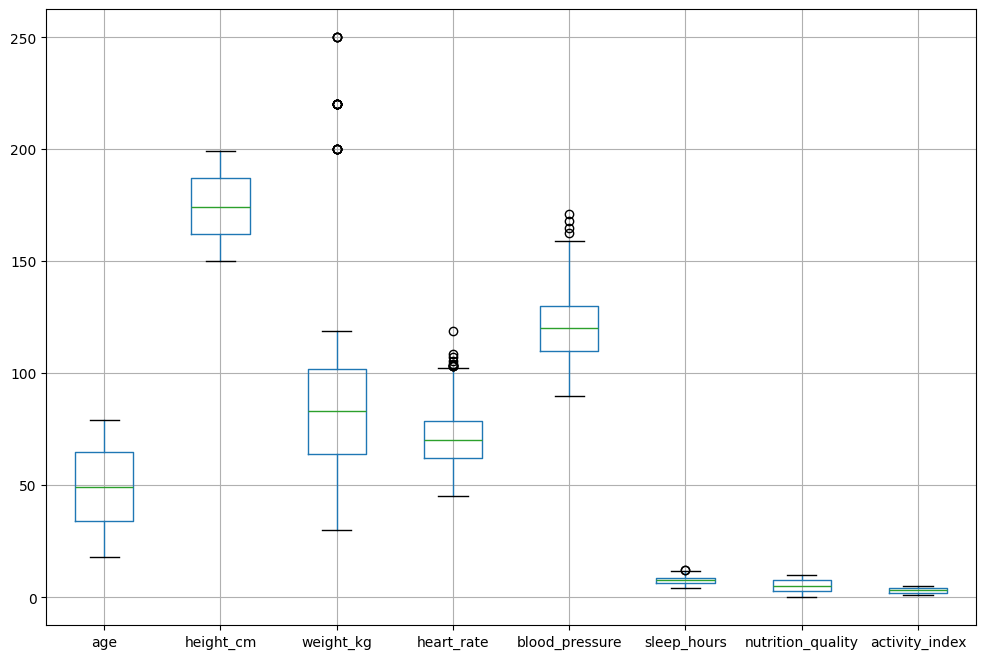

In [ ]:
numeric_cols = ['age', 'height_cm', 'weight_kg', 'heart_rate',
                'blood_pressure', 'sleep_hours',
                'nutrition_quality', 'activity_index']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot() #outliers exist in ['weight_kg','heart_rate','blood_pressure','sleep_hours']



In [ ]:
coulmn_outliers = ['blood_pressure' ,'heart_rate','weight_kg'] #sleep_hours feature distrubution is important
for col in coulmn_outliers:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [ ]:
df.shape

(1965, 11)

<Axes: >

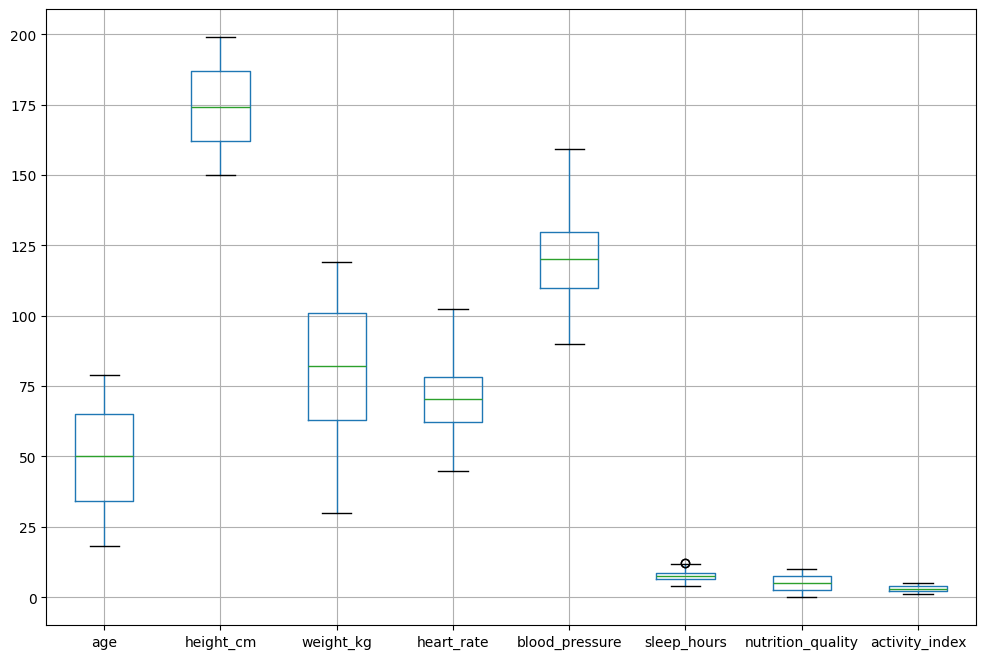

In [ ]:
numeric_cols = ['age', 'height_cm', 'weight_kg', 'heart_rate',
                'blood_pressure', 'sleep_hours',
                'nutrition_quality', 'activity_index']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot()



In [ ]:
df.isnull().sum()

,0
age,0
height_cm,0
weight_kg,0
heart_rate,0
blood_pressure,0
sleep_hours,157
nutrition_quality,0
activity_index,0
smokes,0
gender,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1965 non-null   int64  
 1   height_cm          1965 non-null   int64  
 2   weight_kg          1965 non-null   int64  
 3   heart_rate         1965 non-null   float64
 4   blood_pressure     1965 non-null   float64
 5   sleep_hours        1808 non-null   float64
 6   nutrition_quality  1965 non-null   float64
 7   activity_index     1965 non-null   float64
 8   smokes             1965 non-null   object 
 9   gender             1965 non-null   object 
 10  is_fit             1965 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 184.2+ KB


In [ ]:
df['sleep_hours'].describe()

,sleep_hours
count,1808.000000
mean,7.512334
std,1.505301
min,4.000000
25%,6.500000
50%,7.500000
75%,8.600000
max,12.000000


In [ ]:
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)

In [ ]:
df['smokes'].unique()

array(['no', '0', 'yes', '1'], dtype=object)

In [ ]:
df['smokes'].replace({'no': 0, 'yes': 1}, inplace=True)
df['smokes'] = df['smokes'].astype(int)

In [ ]:
df['smokes'].unique()

array([0, 1])

In [ ]:
df['gender'].unique()

array(['F', 'M'], dtype=object)

In [ ]:
df['gender'] = pd.get_dummies(df['gender'], drop_first=True, dtype=int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1965 non-null   int64  
 1   height_cm          1965 non-null   int64  
 2   weight_kg          1965 non-null   int64  
 3   heart_rate         1965 non-null   float64
 4   blood_pressure     1965 non-null   float64
 5   sleep_hours        1965 non-null   float64
 6   nutrition_quality  1965 non-null   float64
 7   activity_index     1965 non-null   float64
 8   smokes             1965 non-null   int64  
 9   gender             1965 non-null   int64  
 10  is_fit             1965 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 184.2 KB


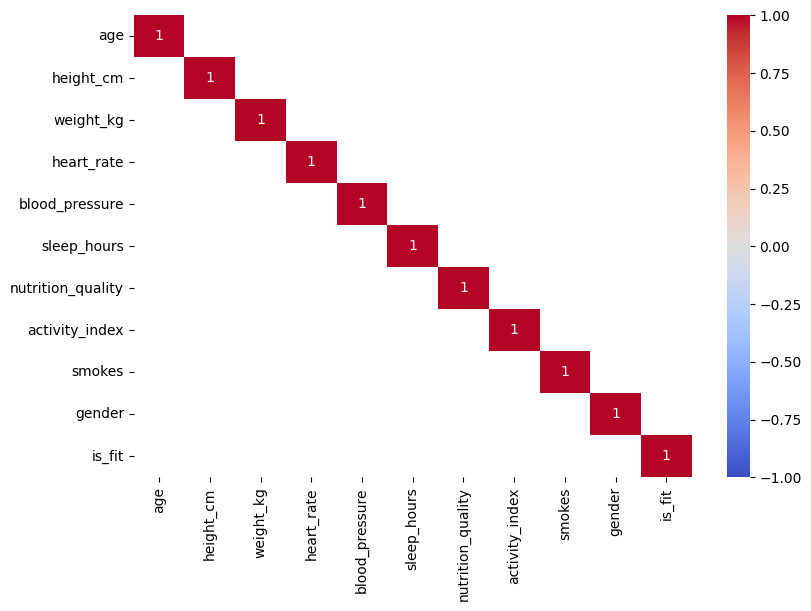

In [ ]:
corr = df.corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm',mask=corr<0.8)
plt.show()

In [ ]:
x = df.drop('is_fit',axis = 1)
y = df['is_fit']

In [ ]:
y.value_counts() #target is slightly imbalanced

,count
is_fit,
0,1178
1,787


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

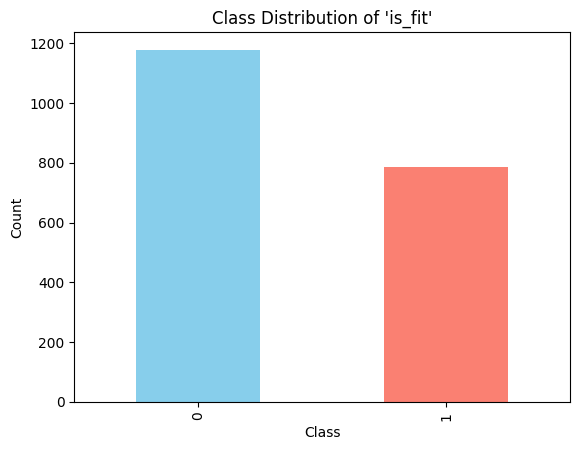

In [ ]:
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution of 'is_fit'")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show() # Target is slightly imbalanced

In [ ]:
smote = SMOTE(random_state=42,sampling_strategy=0.9)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [ ]:
y_train_resampled.value_counts()

,count
is_fit,
0,943
1,848


In [ ]:
tl = TomekLinks()
x_train_resampled, y_train_resampled = tl.fit_resample(x_train_resampled, y_train_resampled)

In [ ]:
y_train_resampled.value_counts()

,count
is_fit,
0,871
1,848


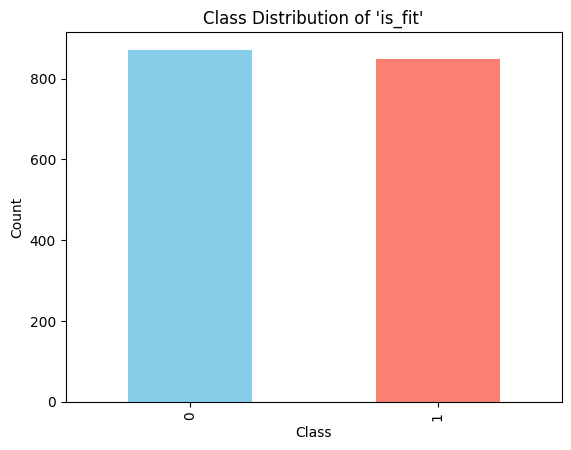

In [ ]:
y_train_resampled.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution of 'is_fit'")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
selector = SelectKBest(score_func=f_classif, k=10)
x_train_resampled = selector.fit_transform(x_train_resampled, y_train_resampled)
x_test = selector.transform(x_test)

In [ ]:
nb = GaussianNB()
nb.fit(x_train_resampled,y_train_resampled)
y_pred = nb.predict(x_test)
y_train_pred = nb.predict(x_train_resampled)
acc_nb = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test,y_pred))

Test score :  0.8269720101781171
Train score :  0.796393251890634
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       235
           1       0.79      0.77      0.78       158

    accuracy                           0.83       393
   macro avg       0.82      0.82      0.82       393
weighted avg       0.83      0.83      0.83       393



In [ ]:
lr = LogisticRegression()
lr.fit(x_train_resampled,y_train_resampled)
y_pred = lr.predict(x_test)
y_train_pred = lr.predict(x_train_resampled)
acc_lr = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test,y_pred))

Test score :  0.821882951653944
Train score :  0.7847585805700988
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       235
           1       0.78      0.78      0.78       158

    accuracy                           0.82       393
   macro avg       0.81      0.82      0.82       393
weighted avg       0.82      0.82      0.82       393



In [ ]:
svm = SVC()
svm.fit(x_train_resampled,y_train_resampled)
y_pred = svm.predict(x_test)
y_train_pred = svm.predict(x_train_resampled)
svc_acc = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test,y_pred))

Test score :  0.821882951653944
Train score :  0.8621291448516579
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       235
           1       0.80      0.74      0.77       158

    accuracy                           0.82       393
   macro avg       0.82      0.81      0.81       393
weighted avg       0.82      0.82      0.82       393



In [ ]:
knn = KNeighborsClassifier(n_neighbors=18,weights='uniform', p=2)
knn.fit(x_train_resampled,y_train_resampled)
y_pred = knn.predict(x_test)
y_train_pred = knn.predict(x_train_resampled)
k_acc = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test,y_pred))


Test score :  0.7786259541984732
Train score :  0.794066317626527
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       235
           1       0.72      0.73      0.73       158

    accuracy                           0.78       393
   macro avg       0.77      0.77      0.77       393
weighted avg       0.78      0.78      0.78       393



In [ ]:
pipe = Pipeline([
    ('rf', RandomForestClassifier())
])

params = {
    'rf__n_estimators': [180,250,300],
    'rf__max_depth': [None,10, 20],
    'rf__max_features': [32],
    'rf__min_samples_leaf': [45],
    'rf__min_samples_split': [25],
    'rf__criterion' : ['gini','entropy']
}

grid = RandomizedSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(x_train_resampled, y_train_resampled)
print(grid.best_params_)
print(grid.best_score_)
model = grid.best_estimator_
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train_resampled)
r_acc = accuracy_score(y_test, y_pred)
print("Test score : ",accuracy_score(y_test, y_pred))
print("Train score : ",accuracy_score(y_train_resampled, y_train_pred))
print(classification_report(y_test, y_pred))

{'rf__n_estimators': 250, 'rf__min_samples_split': 25, 'rf__min_samples_leaf': 45, 'rf__max_features': 32, 'rf__max_depth': None, 'rf__criterion': 'gini'}
0.7597616787578818
Test score :  0.7480916030534351
Train score :  0.7905759162303665
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       235
           1       0.70      0.66      0.68       158

    accuracy                           0.75       393
   macro avg       0.74      0.73      0.74       393
weighted avg       0.75      0.75      0.75       393



In [ ]:
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=20, max_depth=7, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(kernel='linear', C=10)),
    ('knn', KNeighborsClassifier(n_neighbors=20, weights='uniform')),
    ('nb', GaussianNB())
]
meta_estimator = GaussianNB()
stacking_clf = StackingClassifier(estimators=base_estimators, final_estimator=meta_estimator)
stacking_clf.fit(x_train_resampled, y_train_resampled)
y_pred = stacking_clf.predict(x_test)
y_train_pred = stacking_clf.predict(x_train_resampled)
stack_acc = accuracy_score(y_test, y_pred)
print("Test score : ",accuracy_score(y_test, y_pred))
print("Train score : ",accuracy_score(y_train_resampled, y_train_pred))
print(classification_report(y_test, y_pred))

Test score :  0.8320610687022901
Train score :  0.8260616637579988
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       235
           1       0.80      0.78      0.79       158

    accuracy                           0.83       393
   macro avg       0.83      0.82      0.82       393
weighted avg       0.83      0.83      0.83       393



In [ ]:
gb = GradientBoostingClassifier( n_estimators=80,learning_rate=0.05, max_depth=2 )
gb.fit(x_train_resampled,y_train_resampled)
y_pred = gb.predict(x_test)
y_train_pred = gb.predict(x_train_resampled)
acc_gb = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test,y_pred))

Test score :  0.7811704834605598
Train score :  0.806282722513089
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       235
           1       0.73      0.72      0.73       158

    accuracy                           0.78       393
   macro avg       0.77      0.77      0.77       393
weighted avg       0.78      0.78      0.78       393



Test score :  0.7302798982188295
Train score :  0.7835951134380453
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       235
           1       0.65      0.71      0.68       158

    accuracy                           0.73       393
   macro avg       0.72      0.73      0.72       393
weighted avg       0.74      0.73      0.73       393



<Axes: >

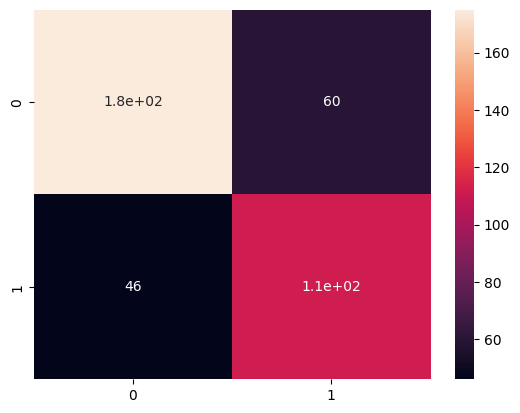

In [ ]:
dt = DecisionTreeClassifier(max_depth=5,max_features=5)
dt.fit(x_train_resampled,y_train_resampled)
y_pred = dt.predict(x_test)
y_pred_train = dt.predict(x_train_resampled)
acc_dt = accuracy_score(y_test,y_pred)
print("Test score : ",accuracy_score(y_test,y_pred))
print("Train score : ",accuracy_score(y_train_resampled,y_pred_train))
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True) #overfitted too complex without hyperparam tunining

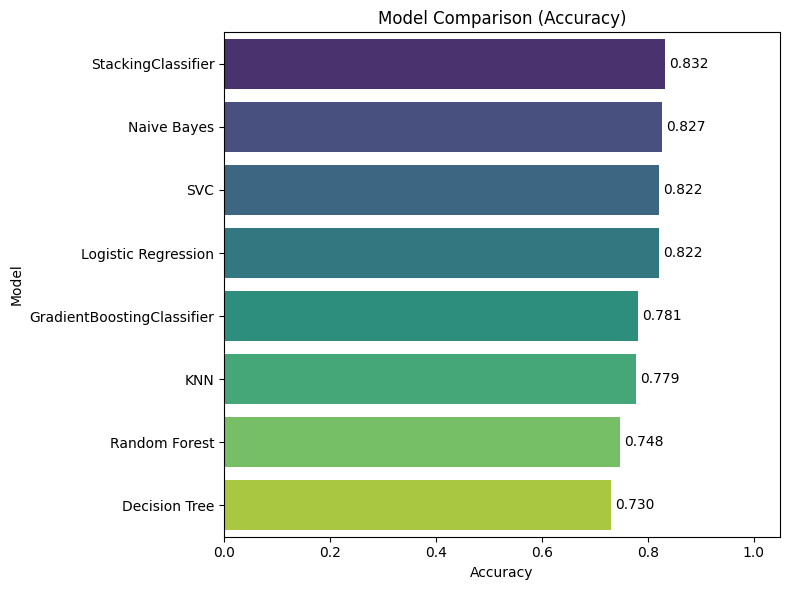

In [ ]:
metrics = {
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree", "KNN", "SVC", "Random Forest", "StackingClassifier","GradientBoostingClassifier"],
    "Accuracy": [acc_lr, acc_nb, acc_dt, k_acc, svc_acc, r_acc, stack_acc,acc_gb],
}

df_metrics = pd.DataFrame(metrics)


df_metrics = df_metrics.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8, 6))


ax = sns.barplot(y="Model", x="Accuracy", data=df_metrics, palette="viridis")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title("Model Comparison (Accuracy)")
plt.xlim(0, 1.05)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()
